# AIRPORT Auction Simulations

Simulation notebook for airport time-slot instances using the AIRPORT heuristic.

In [4]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from AIRPORT_generation import generate_airport_instance
from AIRPORT_heuristic import run_airport_heuristic, run_airport_heuristic_2D_alpha, run_airport_heuristic_2D_beta

rng = np.random.default_rng(0)


In [5]:
# Simulation parameters
num_items_values = [24, 48, 96]
max_cap_values = [4, 6, 8]
num_trials = 20

max_budget = 40

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}


In [ ]:
results = []

for num_items in num_items_values:
    for max_cap in max_cap_values:
        num_players = num_items * (max_cap - 1) // 2

        for trial in range(num_trials):
            seed = int(rng.integers(0, 1_000_000))
            instance = generate_airport_instance(
                num_items=num_items,
                max_cap=max_cap,
                max_budget=max_budget,
                num_players=num_players,
                rng_seed=seed,
            )

            start = perf_counter()
            result = run_airport_heuristic(instance, rng_seed=seed, **heuristic_kwargs)
            demands = result.get("demands", [])
            allocated_players = sum(1 for bundle in demands if len(bundle) > 0)
            allocation_rate = allocated_players / max(1, instance["num_players"])
            elapsed = perf_counter() - start

            history = result.get("meta", {}).get("history", [])
            if history:
                avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
            else:
                avg_change_rate = 0.0
                avg_max_price = 0.0
                avg_price_std = 0.0

            results.append(
                {
                    "num_items": num_items,
                    "max_cap": max_cap,
                    "num_players": num_players,
                    "trial": trial,
                    "slack_found": result.get("slack"),
                    "boosted": result.get("is_boosted", False),
                    "equilibrium": result.get("equilibrium", False),
                    "rounds": result.get("rounds"),
                    "delta_final": result.get("delta"),
                    "time_sec": elapsed,
                    "avg_demand_change": avg_change_rate,
                    "avg_max_price": avg_max_price,
                    "avg_price_std": avg_price_std,
                    "allocated_players": allocated_players,
                    "allocation_rate": allocation_rate,
                }
            )

df = pd.DataFrame(results)
df.head()


In [ ]:
# Summary metrics
summary = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(
        runs=("trial", "count"),
        equilibrium_rate=("equilibrium", "mean"),
        avg_slack=("slack_found", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
        avg_time=("time_sec", "mean"),
        avg_demand_change=("avg_demand_change", "mean"),
        avg_allocated_players=("allocated_players", "mean"),
        avg_allocation_rate=("allocation_rate", "mean"),
    )
    .reset_index()
)
summary


In [ ]:
# Plot: Average Slack Needed vs Num Players
agg_slack = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(avg_slack=("slack_found", "mean"), std_slack=("slack_found", "std"))
    .reset_index()
)

num_items_levels = sorted(df["num_items"].unique())
max_cap_levels = sorted(df["max_cap"].unique())
color_map = {max_cap_levels[0]: "red", max_cap_levels[1]: "green", max_cap_levels[2]: "blue"}
marker_map = {num_items_levels[0]: "o", num_items_levels[1]: "s", num_items_levels[2]: "^"}
offsets = {max_cap_levels[0]: -1.2, max_cap_levels[1]: 0.0, max_cap_levels[2]: 1.2}

fig, ax = plt.subplots(figsize=(9, 5))
for num_items in num_items_levels:
    for max_cap in max_cap_levels:
        subset = agg_slack[(agg_slack["num_items"] == num_items) & (agg_slack["max_cap"] == max_cap)]
        if subset.empty:
            continue
        xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
        ys = subset["avg_slack"].to_numpy(dtype=float)
        errs = subset["std_slack"].fillna(0.0).to_numpy(dtype=float)

        ax.errorbar(
            xs,
            ys,
            yerr=errs,
            fmt=marker_map[num_items],
            color=color_map[max_cap],
            alpha=0.65,
            markersize=8,
            markeredgecolor="black",
            markeredgewidth=0.5,
            linestyle="None",
            capsize=3,
        )

ax.set_xlabel("Number of players")
ax.set_ylabel("Average Slack Needed")
ax.set_title("Average Slack Needed vs Number of Players")
ax.grid(True, linestyle="--", alpha=0.3)

color_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[c], label=f"max_cap={c}", markersize=8)
    for c in max_cap_levels
]
marker_handles = [
    plt.Line2D([0], [0], marker=marker_map[n], color="gray", linestyle="None", label=f"num_items={n}", markersize=8)
    for n in num_items_levels
]
ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
fig.savefig("airport_avg_slack_vs_num_players.png", dpi=200)
print("Saved airport_avg_slack_vs_num_players.png")


In [ ]:
# Plot: Max Slack Needed vs Num Players
agg_max_slack = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(max_slack=("slack_found", "max"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for num_items in num_items_levels:
    for max_cap in max_cap_levels:
        subset = agg_max_slack[(agg_max_slack["num_items"] == num_items) & (agg_max_slack["max_cap"] == max_cap)]
        if subset.empty:
            continue
        xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
        ys = subset["max_slack"].to_numpy(dtype=float)

        ax.scatter(
            xs,
            ys,
            c=color_map[max_cap],
            marker=marker_map[num_items],
            alpha=0.65,
            s=80,
            edgecolor="black",
            linewidth=0.5,
        )

ax.set_xlabel("Number of players")
ax.set_ylabel("Max Slack Needed")
ax.set_title("Max Slack Needed vs Number of Players")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
fig.savefig("airport_max_slack_vs_num_players.png", dpi=200)
print("Saved airport_max_slack_vs_num_players.png")


In [ ]:
# Plot: Average Demand Change vs Num Players
agg_change = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(avg_change=("avg_demand_change", "mean"), std_change=("avg_demand_change", "std"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for num_items in num_items_levels:
    for max_cap in max_cap_levels:
        subset = agg_change[(agg_change["num_items"] == num_items) & (agg_change["max_cap"] == max_cap)]
        if subset.empty:
            continue
        xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
        ys = subset["avg_change"].to_numpy(dtype=float)
        errs = subset["std_change"].fillna(0.0).to_numpy(dtype=float)

        ax.errorbar(
            xs,
            ys,
            yerr=errs,
            fmt=marker_map[num_items],
            color=color_map[max_cap],
            alpha=0.65,
            markersize=8,
            markeredgecolor="black",
            markeredgewidth=0.5,
            linestyle="None",
            capsize=3,
        )

ax.set_xlabel("Number of players")
ax.set_ylabel("Average Demand Change")
ax.set_title("Average Demand Change vs Number of Players")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
fig.savefig("airport_avg_demand_change_vs_num_players.png", dpi=200)
print("Saved airport_avg_demand_change_vs_num_players.png")


In [ ]:
# Additional diagnostics vs Num Players
perf = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(
        eq_rate=("equilibrium", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
        std_rounds=("rounds", "std"),
        avg_time=("time_sec", "mean"),
        std_time=("time_sec", "std"),
        avg_max_price=("avg_max_price", "mean"),
        std_max_price=("avg_max_price", "std"),
        avg_price_std=("avg_price_std", "mean"),
        std_price_std=("avg_price_std", "std"),
    )
    .reset_index()
)

def _plot_airport_metric(metric, std_col, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(9, 5))
    for num_items in num_items_levels:
        for max_cap in max_cap_levels:
            subset = perf[(perf["num_items"] == num_items) & (perf["max_cap"] == max_cap)]
            if subset.empty:
                continue
            xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
            ys = subset[metric].to_numpy(dtype=float)

            if std_col is None:
                ax.scatter(
                    xs, ys,
                    c=color_map[max_cap],
                    marker=marker_map[num_items],
                    alpha=0.65,
                    s=80,
                    edgecolor="black",
                    linewidth=0.5,
                )
            else:
                errs = subset[std_col].fillna(0.0).to_numpy(dtype=float)
                ax.errorbar(
                    xs, ys,
                    yerr=errs,
                    fmt=marker_map[num_items],
                    color=color_map[max_cap],
                    alpha=0.65,
                    markersize=8,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    linestyle="None",
                    capsize=3,
                )

    ax.set_xlabel("Number of players")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")
    return fig, ax

_plot_airport_metric("eq_rate", None, "Equilibrium Rate", "Equilibrium Rate vs Number of Players", "airport_eq_rate_vs_num_players.png")
_plot_airport_metric("boost_rate", None, "Boost Usage Rate", "Boost Usage Rate vs Number of Players", "airport_boost_rate_vs_num_players.png")
_plot_airport_metric("avg_rounds", "std_rounds", "Average Rounds", "Average Rounds vs Number of Players", "airport_avg_rounds_vs_num_players.png")
_plot_airport_metric("avg_time", "std_time", "Average Runtime (s)", "Average Runtime vs Number of Players", "airport_avg_time_vs_num_players.png")
_plot_airport_metric("avg_max_price", "std_max_price", "Average Max Price", "Average Max Price vs Number of Players", "airport_avg_max_price_vs_num_players.png")
_plot_airport_metric("avg_price_std", "std_price_std", "Average Price Std Dev", "Average Price Std Dev vs Number of Players", "airport_avg_price_std_vs_num_players.png")


In [ ]:
# Plot: Players with a won pair vs Num Players
agg_alloc = (
    df.groupby(["num_items", "max_cap", "num_players"])
    .agg(
        avg_allocated_players=("allocated_players", "mean"),
        std_allocated_players=("allocated_players", "std"),
        avg_allocation_rate=("allocation_rate", "mean"),
        std_allocation_rate=("allocation_rate", "std"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
for num_items in num_items_levels:
    for max_cap in max_cap_levels:
        subset = agg_alloc[(agg_alloc["num_items"] == num_items) & (agg_alloc["max_cap"] == max_cap)]
        if subset.empty:
            continue
        xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
        ys = subset["avg_allocated_players"].to_numpy(dtype=float)
        errs = subset["std_allocated_players"].fillna(0.0).to_numpy(dtype=float)

        ax.errorbar(
            xs,
            ys,
            yerr=errs,
            fmt=marker_map[num_items],
            color=color_map[max_cap],
            alpha=0.65,
            markersize=8,
            markeredgecolor="black",
            markeredgewidth=0.5,
            linestyle="None",
            capsize=3,
        )

ax.set_xlabel("Number of players")
ax.set_ylabel("Average players with a won pair")
ax.set_title("Players with a Won Pair vs Number of Players")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
fig.savefig("airport_allocated_players_vs_num_players.png", dpi=200)
print("Saved airport_allocated_players_vs_num_players.png")

# Optional normalised version (share of airlines served)
fig, ax = plt.subplots(figsize=(9, 5))
for num_items in num_items_levels:
    for max_cap in max_cap_levels:
        subset = agg_alloc[(agg_alloc["num_items"] == num_items) & (agg_alloc["max_cap"] == max_cap)]
        if subset.empty:
            continue
        xs = subset["num_players"].to_numpy(dtype=float) + offsets[max_cap]
        ys = subset["avg_allocation_rate"].to_numpy(dtype=float)
        errs = subset["std_allocation_rate"].fillna(0.0).to_numpy(dtype=float)

        ax.errorbar(
            xs,
            ys,
            yerr=errs,
            fmt=marker_map[num_items],
            color=color_map[max_cap],
            alpha=0.65,
            markersize=8,
            markeredgecolor="black",
            markeredgewidth=0.5,
            linestyle="None",
            capsize=3,
        )

ax.set_xlabel("Number of players")
ax.set_ylabel("Average allocation rate")
ax.set_title("Allocation Rate vs Number of Players")
ax.set_ylim(0.0, 1.05)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.tight_layout()
fig.savefig("airport_allocation_rate_vs_num_players.png", dpi=200)
print("Saved airport_allocation_rate_vs_num_players.png")


**Hill Climbing Algorithm for Manipulations**

In [ ]:
import copy
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from AIRPORT_generation import generate_airport_instance
from AIRPORT_heuristic import run_airport_heuristic, hill_climb_manipulation_airport, expected_utility_airport


# --- GLOBAL EXPERIMENT PARAMETERS ---
max_cap = 4
max_budget = 40
market_sizes = [ 96, 48, 24]
num_tries = 15 
eta = 2.0
explore_samples = 7
verify_samples = 25
max_iters = 5

summary_results = []
item_data_list = [] # Master list for congestion analytics
os.makedirs('./airport_figs_new', exist_ok=True)

print(f"Starting Multi-Scale Market Search for AIRPORT...")
print("=" * 60)

for num_items in market_sizes:
    num_players = num_items * (max_cap - 1) // 2
    
    base_instance_params = {
        "num_items": num_items,
        "max_cap": max_cap,
        "max_budget": max_budget,
        "num_players": num_players
    }
    
    print(f"\nEvaluating Market Size: {num_items} items, {num_players} players")
    print("-" * 60)
    
    master_seed = 42 + num_items
    np.random.seed(master_seed)
    master_instance = generate_airport_instance(**base_instance_params, rng_seed=master_seed)
    
    fixed_schedules = [
        {'wait': p['wait'], 'arrival': p['arrival'], 'departure': p['departure']} 
        for p in master_instance['players']
    ]
    
    pct_histories_matrix = []
    success_histories_matrix = []

    for trial in range(num_tries):
        target_player = np.random.randint(0, num_players)
        target_budget = master_instance["budgets"][target_player]
        true_feasible_pairs = copy.deepcopy(master_instance["players"][target_player]["feasible_pairs"])
        
        # NEW: Unpack price_history as well
        best_fake_bid, history, price_hist = hill_climb_manipulation_airport(
            target_player_id=target_player,
            base_instance_params=base_instance_params,
            fixed_schedules=fixed_schedules,
            target_budget=target_budget,
            true_feasible_pairs=true_feasible_pairs,
            eta=eta,
            explore_samples=explore_samples,
            verify_samples=verify_samples,
            max_iters=max_iters
        )
        
        padded_history = history.copy()
        while len(padded_history) < max_iters + 1:
            padded_history.append(padded_history[-1])
            
        base_u = padded_history[0]
        final_u = padded_history[-1]
        
        if base_u > 0.01:
            pct_traj = [((u - base_u) / base_u) * 100 for u in padded_history]
        else:
            pct_traj = [0.0 for _ in padded_history]
            
        success = final_u > base_u + 1e-5
        success_traj = [1.0 if u > base_u + 1e-5 else 0.0 for u in padded_history]
        
        pct_histories_matrix.append(pct_traj)
        success_histories_matrix.append(success_traj)
        
        # ==========================================
        # CONGESTION ANALYTICS (On Successful Manipulations)
        # ==========================================
        if success:
            # 1. Calculate base congestion
            item_congestion = collections.defaultdict(int)
            for p in master_instance["players"]:
                if p["id"] == target_player: continue
                interested_items = set()
                for pair_info in p["feasible_pairs"]:
                    interested_items.add(pair_info["pair"][0])
                    interested_items.add(pair_info["pair"][1])
                for j in interested_items:
                    item_congestion[j] += 1
            
            # 2. Calculate average dV (Utility Change) for targeted items
            item_dV_sums = collections.defaultdict(float)
            item_dV_counts = collections.defaultdict(int)
            for true_p, fake_p in zip(true_feasible_pairs, best_fake_bid):
                pair = true_p["pair"]
                delta_v = fake_p["utility"] - true_p["utility"]
                for j in pair:
                    item_dV_sums[j] += delta_v
                    item_dV_counts[j] += 1
                    
            # 3. Use the tracked prices from the hill climber!
            avg_true_prices = price_hist[0]
            avg_fake_prices = price_hist[-1]
            
            # 4. Append to item master list
            for j in item_dV_counts.keys():
                avg_dv = item_dV_sums[j] / item_dV_counts[j]
                dp = avg_fake_prices[j] - avg_true_prices[j]
                item_data_list.append({
                    "num_players": num_players,
                    "trial": trial,
                    "item_id": j,
                    "congestion": item_congestion[j],
                    "dV": avg_dv,
                    "dP": dp
                })

    summary_results.append({
        'num_players': num_players,
        'num_items': num_items,
        'pct_histories': np.array(pct_histories_matrix),
        'success_histories': np.array(success_histories_matrix)
    })



Starting Multi-Scale Market Search for AIRPORT...

Evaluating Market Size: 96 items, 144 players
------------------------------------------------------------
Starting Truthful Expected Utility (25 samples): 44.70
Iteration 1: Found verified improvement! New Utility: 44.75
Iteration 2: Found verified improvement! New Utility: 44.82
Iteration 3: No local tweaks passed 50-sample verification. Stopping.
Starting Truthful Expected Utility (25 samples): 41.71
Iteration 1: Found verified improvement! New Utility: 41.83
Iteration 2: No local tweaks passed 50-sample verification. Stopping.
Starting Truthful Expected Utility (25 samples): 61.67
Iteration 1: Found verified improvement! New Utility: 61.78
Iteration 2: Found verified improvement! New Utility: 61.81
Iteration 3: No local tweaks passed 50-sample verification. Stopping.
Starting Truthful Expected Utility (25 samples): 79.75
Iteration 1: Found verified improvement! New Utility: 79.87
Iteration 2: No local tweaks passed 50-sample verifi

In [ ]:
df_items = pd.DataFrame(item_data_list)
df_items.to_csv("airport_data/airport_manipulation_item_stats_all_configs_NEW.csv", index=False)
np.save("airport_data/airport_manipulation_summary_results_NEW.npy", summary_results, allow_pickle=True)
all_pct = [res['pct_histories'] for res in summary_results]
all_success = [res['success_histories'] for res in summary_results]

np.save("airport_data/airport_manipulation_pct_histories_NEW.npy", all_pct, allow_pickle=True)
np.save("airport_data/airport_manipulation_success_histories_NEW.npy", all_success, allow_pickle=True)

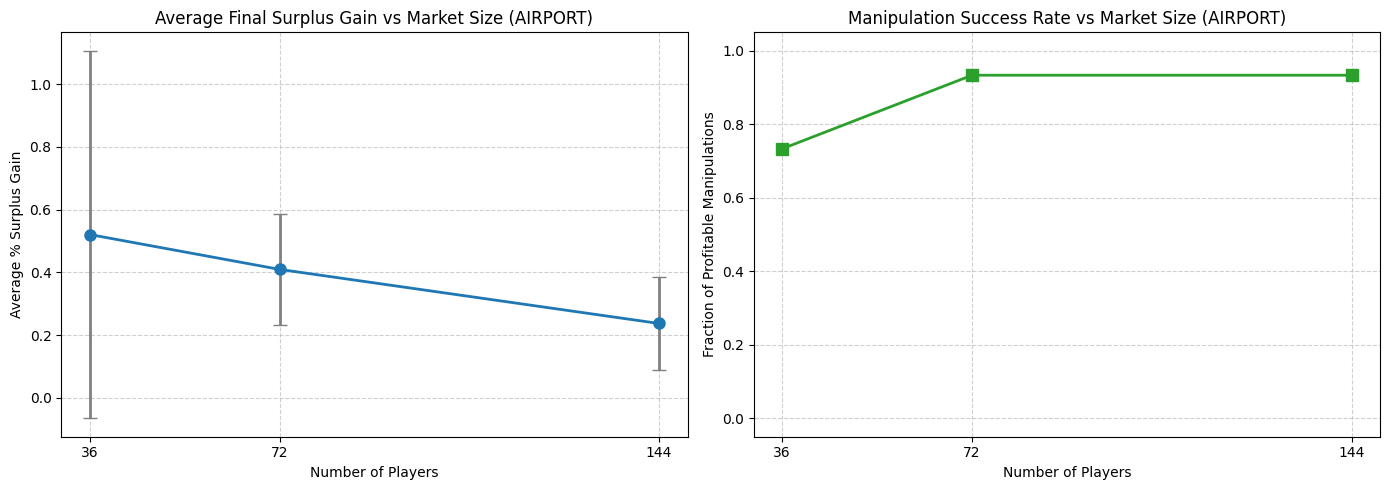

In [ ]:

# ==========================================
# PLOTTING (Mirrored from GRID with Errors)
# ==========================================
players_axis = []
avg_pct_gain = []
pct_err = []
success_rate = []
success_err = []

# Sort to ensure left-to-right line plots
#summary_results = sorted(summary_results, key=lambda x: x['num_players'])

for res in summary_results:
    players_axis.append(res['num_players'])
    
    # Extract the final iteration's results
    final_pcts = res['pct_histories'][:, -1]
    final_successes = res['success_histories'][:, -1]
    
    avg_pct_gain.append(np.nanmean(final_pcts)) # Already multiplied by 100 in loop above
    success_rate.append(np.nanmean(final_successes))
    
    # Error bar math (Standard Deviation)
    pct_err.append(np.nanstd(final_pcts))
    success_err.append(np.nanstd(final_successes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: % Gain vs Num Players
axes[0].errorbar(players_axis, avg_pct_gain, yerr=pct_err, 
                 marker='o', color='#1f77b4', linewidth=2, markersize=8,
                 capsize=5, capthick=1, ecolor='gray')
axes[0].set_title('Average Final Surplus Gain vs Market Size (AIRPORT)')
axes[0].set_xlabel('Number of Players')
axes[0].set_ylabel('Average % Surplus Gain')
axes[0].set_xticks(players_axis)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Success Rate vs Num Players
axes[1].plot(players_axis, success_rate,
                 marker='s', color='#2ca02c', linewidth=2, markersize=8)
axes[1].set_title('Manipulation Success Rate vs Market Size (AIRPORT)')
axes[1].set_xlabel('Number of Players')
axes[1].set_ylabel('Fraction of Profitable Manipulations')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xticks(players_axis)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
#Optional: save figure
fig.savefig('./airport_figs_new/unified_market_size_impact_with_errors.png', dpi=300, bbox_inches='tight')
plt.show()

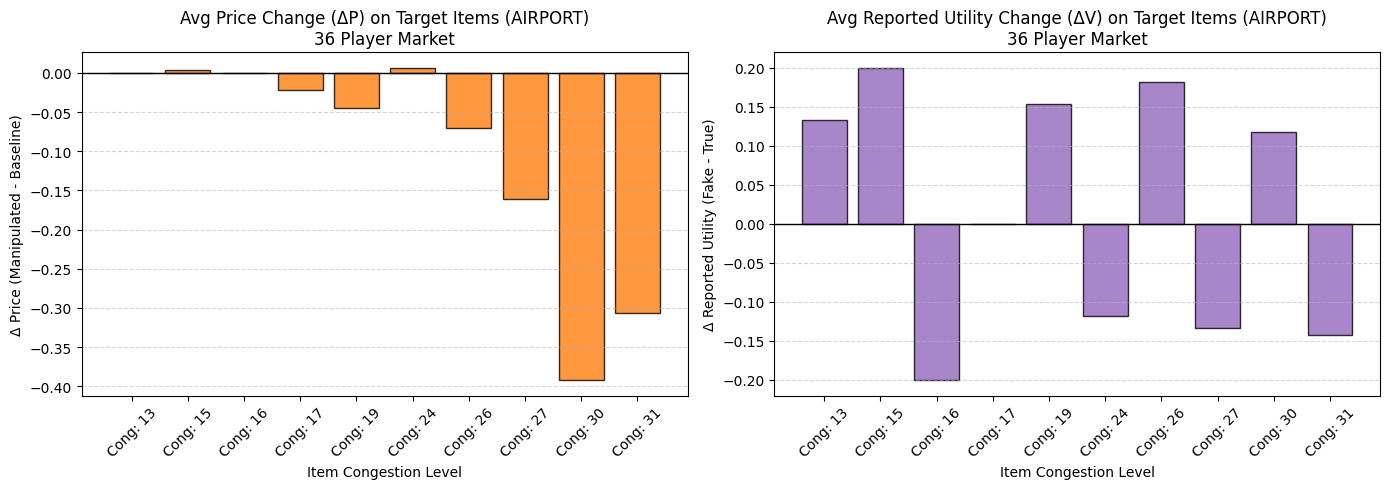

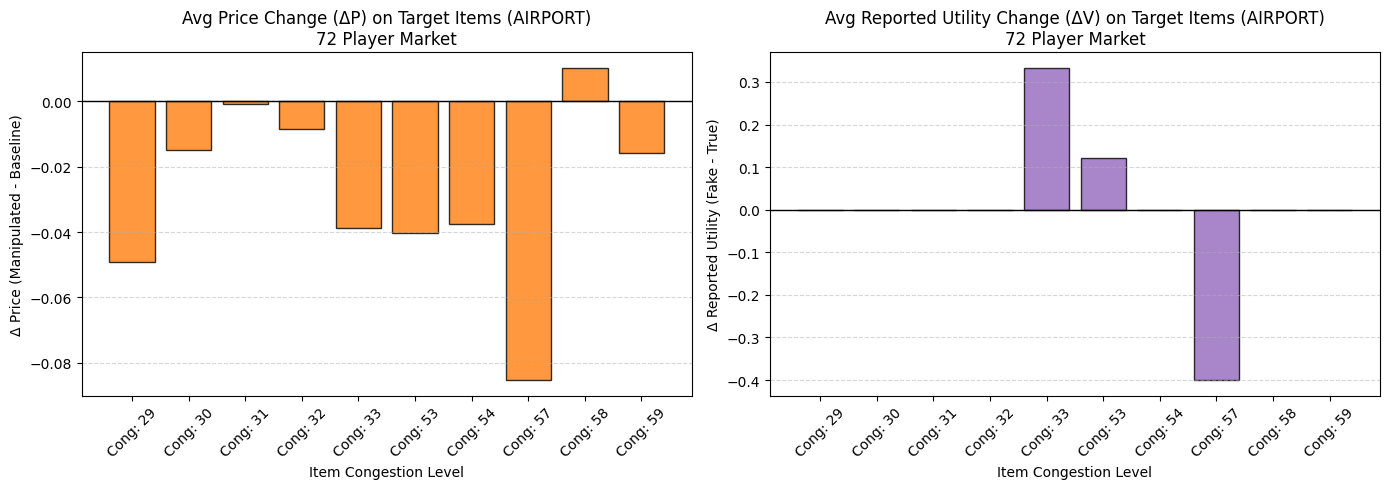

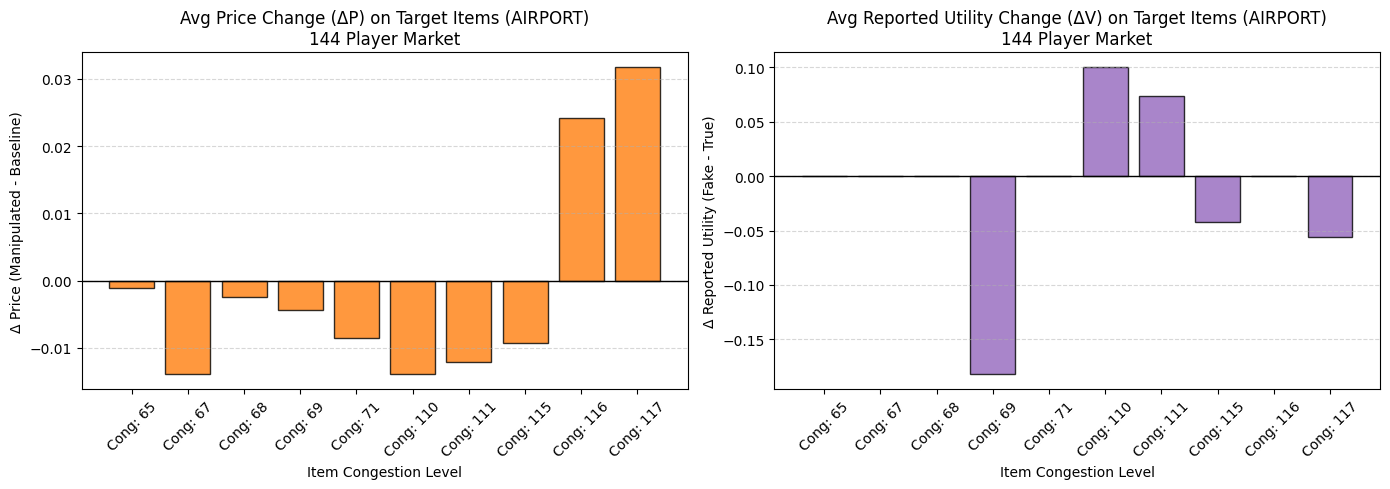

In [ ]:
# ==========================================
# PLOTTING: Item-Level Congestion 
# (This remains exactly the same)
# ==========================================
item_df_master = pd.DataFrame(item_data_list)
unique_configs = sorted(item_df_master['num_players'].unique())

for n_players in unique_configs:
    subset_df = item_df_master[item_df_master['num_players'] == n_players]
    
    if subset_df.empty:
        print(f"No successful manipulations to plot for {n_players} players.")
        continue

    agg_df = subset_df.groupby('congestion')[['dP', 'dV']].mean().reset_index()
    agg_df = agg_df.sort_values('congestion')
    
    least_congested = agg_df.head(5)
    most_congested = agg_df.tail(5)
    
    combined = pd.concat([least_congested, most_congested]).drop_duplicates().sort_values('congestion')
    combined['label'] = combined['congestion'].apply(lambda c: f"Cong: {int(c)}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Price Change vs Congestion
    axes[0].bar(combined['label'], combined['dP'], color='#ff7f0e', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Avg Price Change (ΔP) on Target Items (AIRPORT)\n{n_players} Player Market')
    axes[0].set_xlabel('Item Congestion Level')
    axes[0].set_ylabel('Δ Price (Manipulated - Baseline)')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

    # Plot Utility Change vs Congestion
    axes[1].bar(combined['label'], combined['dV'], color='#9467bd', edgecolor='black', alpha=0.8)
    axes[1].set_title(f'Avg Reported Utility Change (ΔV) on Target Items (AIRPORT)\n{n_players} Player Market')
    axes[1].set_xlabel('Item Congestion Level')
    axes[1].set_ylabel('Δ Reported Utility (Fake - True)')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    fig.savefig(f'./airport_figs_new/item_level_analytics_{n_players}players.png', dpi=300, bbox_inches='tight')
    plt.show()

**ALPHA vs BETA Tradeoffs**

In [ ]:
### ALPHA Prioritization version ###

import pandas as pd
from time import perf_counter
import numpy as np

# Simulation parameters
num_items_values = [24,48,96]
max_cap_values = [4, 6, 8]
num_trials = 20
max_budget = 40

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

results = []

for num_items in num_items_values:
    for max_cap in max_cap_values:
        num_players = num_items * (max_cap - 1) // 2

        for trial in range(num_trials):
            # Assuming rng is a numpy random Generator created previously
            seed = int(rng.integers(0, 1_000_000)) 
            instance = generate_airport_instance(
                num_items=num_items,
                max_cap=max_cap,
                max_budget=max_budget,
                num_players=num_players,
                rng_seed=seed,
            )

            start = perf_counter()
            result = run_airport_heuristic_2D_alpha(instance, rng_seed=seed, **heuristic_kwargs)
            demands = result.get("demands", [])
            allocated_players = sum(1 for bundle in demands if len(bundle) > 0)
            allocation_rate = allocated_players / max(1, instance["num_players"])
            elapsed = perf_counter() - start

            history = result.get("meta", {}).get("history", [])
            if history:
                avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
            else:
                avg_change_rate = 0.0
                avg_max_price = 0.0
                avg_price_std = 0.0

            results.append(
                {
                    "num_items": num_items,
                    "max_cap": max_cap,
                    "num_players": num_players,
                    "trial": trial,
                    "alpha_found": result.get("alpha"),  # Storing 2D alpha
                    "beta_found": result.get("beta"),    # Storing 2D beta
                    "boosted": result.get("is_boosted", False),
                    "equilibrium": result.get("equilibrium", False),
                    "rounds": result.get("rounds"),
                    "delta_final": result.get("delta"),
                    "time_sec": elapsed,
                    "avg_demand_change": avg_change_rate,
                    "avg_max_price": avg_max_price,
                    "avg_price_std": avg_price_std,
                    "allocated_players": allocated_players,
                    "allocation_rate": allocation_rate,
                }
            )
    print(f"Completed simulations for num_items={num_items}")

df_A = pd.DataFrame(results)
df_A.describe()

Completed simulations for num_items=24
Completed simulations for num_items=48
Completed simulations for num_items=96


,num_items,max_cap,num_players,trial,alpha_found,beta_found,rounds,delta_final,time_sec,avg_demand_change,avg_max_price,avg_price_std,allocated_players,allocation_rate
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.0
mean,56.000000,6.000000,140.000000,9.500000,1.433333,0.005556,36.338889,0.394444,3.572502,0.242820,2.245593,0.608391,140.000000,1.0
std,30.016755,1.637548,91.292397,5.782366,0.626242,0.074536,33.265676,0.123823,5.620225,0.050407,1.059283,0.340934,91.292397,0.0
min,24.000000,4.000000,36.000000,0.000000,0.000000,0.000000,1.000000,0.250000,0.008440,0.109059,0.958635,0.247271,36.000000,1.0
25%,24.000000,4.000000,72.000000,4.750000,1.000000,0.000000,6.000000,0.250000,0.386607,0.208673,1.462326,0.372432,72.000000,1.0
50%,48.000000,6.000000,120.000000,9.500000,1.000000,0.000000,14.000000,0.500000,0.896801,0.244523,1.924353,0.502565,120.000000,1.0
75%,96.000000,8.000000,168.000000,14.250000,2.000000,0.000000,73.000000,0.500000,3.158501,0.275644,2.572590,0.689410,168.000000,1.0
max,96.000000,8.000000,336.000000,19.000000,3.000000,1.000000,100.000000,0.500000,24.280452,0.353577,6.793493,2.050847,336.000000,1.0


In [ ]:
### BETA Prioritization version ###

import pandas as pd
from time import perf_counter
import numpy as np

# Simulation parameters
num_items_values = [24,48,96]
max_cap_values = [4, 6, 8]
num_trials = 20
max_budget = 40

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

results = []

for num_items in num_items_values:
    for max_cap in max_cap_values:
        num_players = num_items * (max_cap - 1) // 2

        for trial in range(num_trials):
            # Assuming rng is a numpy random Generator created previously
            seed = int(rng.integers(0, 1_000_000)) 
            instance = generate_airport_instance(
                num_items=num_items,
                max_cap=max_cap,
                max_budget=max_budget,
                num_players=num_players,
                rng_seed=seed,
            )

            start = perf_counter()
            result = run_airport_heuristic_2D_beta(instance, rng_seed=seed, **heuristic_kwargs)
            demands = result.get("demands", [])
            allocated_players = sum(1 for bundle in demands if len(bundle) > 0)
            allocation_rate = allocated_players / max(1, instance["num_players"])
            elapsed = perf_counter() - start

            history = result.get("meta", {}).get("history", [])
            if history:
                avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
            else:
                avg_change_rate = 0.0
                avg_max_price = 0.0
                avg_price_std = 0.0

            results.append(
                {
                    "num_items": num_items,
                    "max_cap": max_cap,
                    "num_players": num_players,
                    "trial": trial,
                    "alpha_found": result.get("alpha"),  # Storing 2D alpha
                    "beta_found": result.get("beta"),    # Storing 2D beta
                    "boosted": result.get("is_boosted", False),
                    "equilibrium": result.get("equilibrium", False),
                    "rounds": result.get("rounds"),
                    "delta_final": result.get("delta"),
                    "time_sec": elapsed,
                    "avg_demand_change": avg_change_rate,
                    "avg_max_price": avg_max_price,
                    "avg_price_std": avg_price_std,
                    "allocated_players": allocated_players,
                    "allocation_rate": allocation_rate,
                }
            )
    print(f"Completed simulations for num_items={num_items}")

df_B = pd.DataFrame(results)
df_B.describe()

Completed simulations for num_items=24
Completed simulations for num_items=48
Completed simulations for num_items=96


,num_items,max_cap,num_players,trial,alpha_found,beta_found,rounds,delta_final,time_sec,avg_demand_change,avg_max_price,avg_price_std,allocated_players,allocation_rate
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,56.000000,6.000000,140.000000,9.500000,1.311111,0.100000,46.105556,0.358333,5.468089,0.235915,2.240501,0.606657,139.988889,0.999815
std,30.016755,1.637548,91.292397,5.782366,0.552181,0.300837,35.182286,0.124229,7.571078,0.048245,1.369034,0.469608,91.302248,0.001752
min,24.000000,4.000000,36.000000,0.000000,0.000000,0.000000,1.000000,0.250000,0.005023,0.109005,0.889821,0.233833,36.000000,0.983333
25%,24.000000,4.000000,72.000000,4.750000,1.000000,0.000000,8.000000,0.250000,0.631254,0.201785,1.444094,0.349610,72.000000,1.000000
50%,48.000000,6.000000,120.000000,9.500000,1.000000,0.000000,71.000000,0.250000,1.620361,0.235836,1.871740,0.447215,120.000000,1.000000
75%,96.000000,8.000000,168.000000,14.250000,2.000000,0.000000,73.000000,0.500000,5.462760,0.265477,2.545058,0.689120,168.000000,1.000000
max,96.000000,8.000000,336.000000,19.000000,3.000000,1.000000,196.000000,0.500000,35.093011,0.350842,13.301900,4.635379,336.000000,1.000000


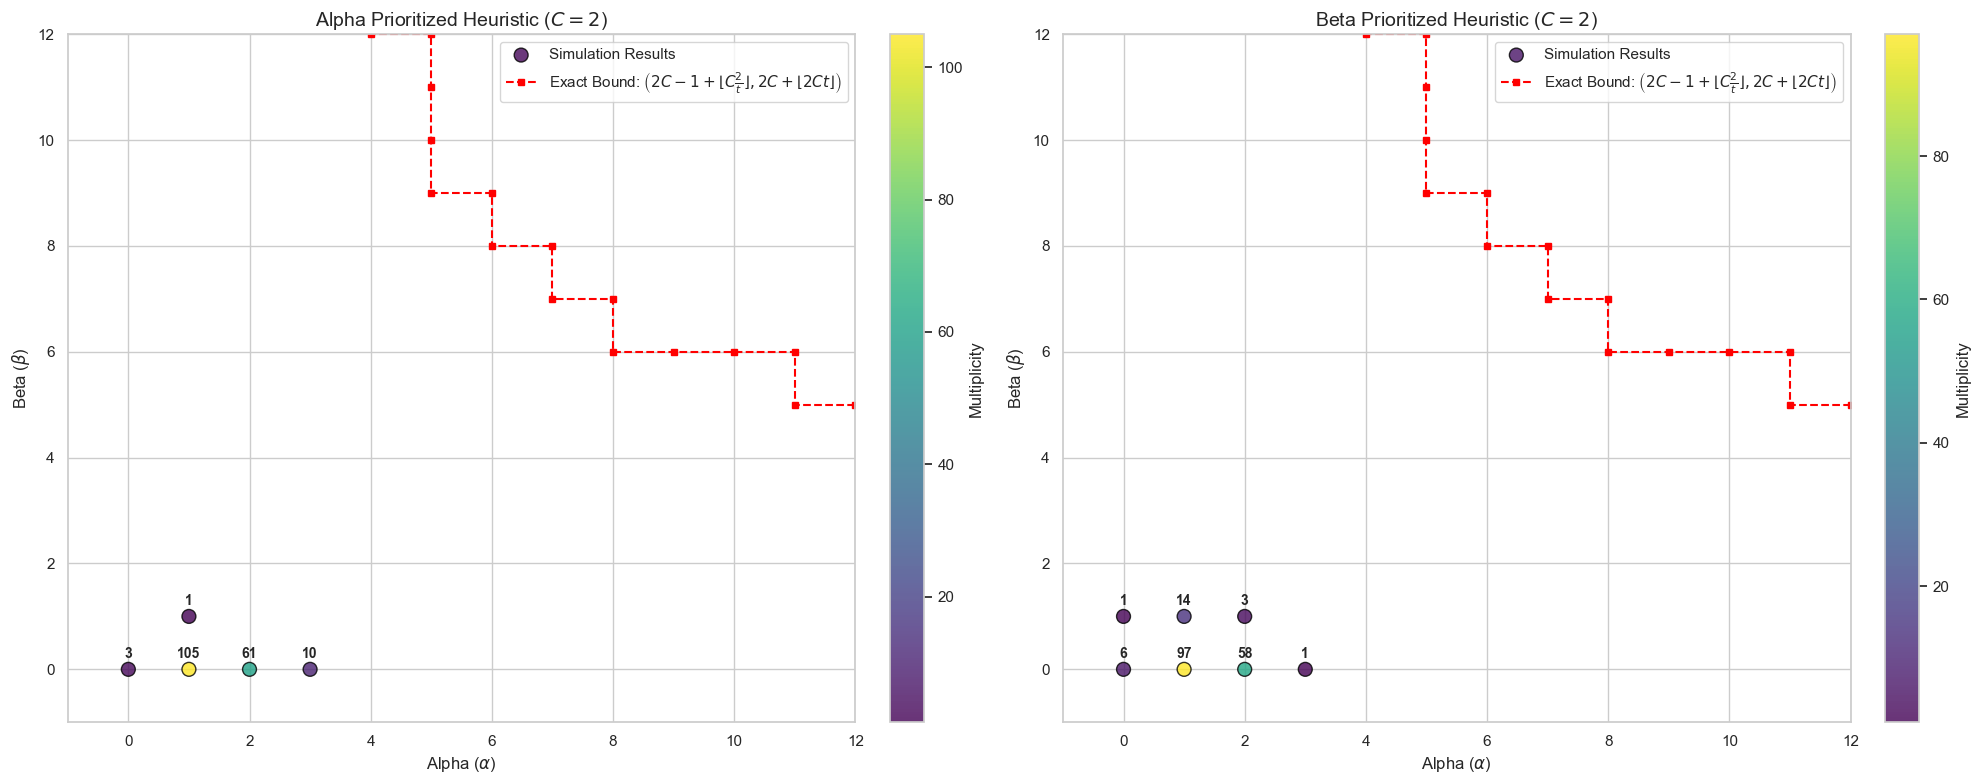

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for cleaner plots
sns.set_theme(style="whitegrid")

# 1. Group data to get the multiplicity of each (alpha, beta) pair for both DFs
pair_counts_A = df_A.groupby(['alpha_found', 'beta_found']).size().reset_index(name='multiplicity')
pair_counts_B = df_B.groupby(['alpha_found', 'beta_found']).size().reset_index(name='multiplicity')

# Determine reasonable global limits for both plots to ensure the axes match for fair comparison
max_x = max(
    pair_counts_A['alpha_found'].max() if not pair_counts_A.empty else 0, 
    pair_counts_B['alpha_found'].max() if not pair_counts_B.empty else 0, 
    10
) + 2

max_y = max(
    pair_counts_A['beta_found'].max() if not pair_counts_A.empty else 0, 
    pair_counts_B['beta_found'].max() if not pair_counts_B.empty else 0, 
    10
) + 2

# 2. Calculate the exact theoretical bound once (Discrete)
C = 2
k_vals = np.arange(1, 500)
m_vals = np.arange(1, 500)
t_jumps_beta = k_vals / (2 * C)         
t_jumps_alpha = (2 * C) / m_vals        
t_dense = np.logspace(-2, 2, 10000)     

# Combine and sort all t values
t_vals = np.sort(np.unique(np.concatenate([t_dense, t_jumps_beta, t_jumps_alpha])))

# Compute the exact coordinates, rounding slightly before floor to fix floating point math errors
val_alpha = np.round((2 * C) / t_vals, 10)
bound_alpha = (2 * C - 1) + np.floor(val_alpha)

val_beta = np.round(2 * C * t_vals, 10)
bound_beta = 2 * C + np.floor(val_beta)

# Combine into coordinate pairs
pairs = np.column_stack((bound_alpha, bound_beta))

# Get unique points while PRESERVING order
_, idx = np.unique(pairs, axis=0, return_index=True)
bound_points = pairs[np.sort(idx)]

# Filter out the points that stretch to infinity
valid_points = bound_points[(bound_points[:, 0] <= max_x) & (bound_points[:, 1] <= max_y)]

# 3. Create the side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Helper function to plot a dataframe on a specific axis
def plot_subplot(ax, pair_counts, title):
    # Plot the (alpha, beta) pairs
    scatter = ax.scatter(
        x=pair_counts['alpha_found'], 
        y=pair_counts['beta_found'], 
        s=100, 
        c=pair_counts['multiplicity'], 
        cmap='viridis', 
        edgecolors='black',
        alpha=0.8,
        zorder=3,
        label='Simulation Results'
    )

    # Add colorbar to show multiplicity scale
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Multiplicity')

    # Write the multiplicity above each point
    for _, row in pair_counts.iterrows():
        ax.text(
            row['alpha_found'], 
            row['beta_found'] + 0.15,  
            str(int(row['multiplicity'])),
            ha='center', 
            va='bottom',
            fontsize=10,
            fontweight='bold',
            zorder=4
        )

    # Plot the exact theoretical bound
    ax.plot(
        valid_points[:, 0], 
        valid_points[:, 1], 
        color='red', 
        linestyle='--', 
        marker='s',        
        markersize=5,
        linewidth=1.5, 
        zorder=2,
        label=r'Exact Bound: $\left(2C-1+\lfloor C\frac{2}{t}\rfloor, 2C+ \lfloor 2C t\rfloor\right)$'
    )

    # Formatting the subplot
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'Alpha ($\alpha$)', fontsize=12)
    ax.set_ylabel(r'Beta ($\beta$)', fontsize=12)

    # Ensure integer ticks for alpha and beta
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Apply globally matched limits
    ax.set_xlim(-1, max_x)
    ax.set_ylim(-1, max_y)

    ax.legend(loc='upper right')

# 4. Render plots on both axes
plot_subplot(axes[0], pair_counts_A, 'Alpha Prioritized Heuristic ($C=2$)')
plot_subplot(axes[1], pair_counts_B, 'Beta Prioritized Heuristic ($C=2$)')

plt.tight_layout()
plt.show()

# Save the figure
fig.savefig("airport_figs_new/airport_alpha_beta_comparison.png", dpi=200)